# Decision Tree

<pre>
============================================================
Test Set Performance
============================================================
Accuracy:  0.9451 (94.51%)
Precision: 0.7658
Recall:    0.8731
F1 Score:  0.8160
============================================================

<pre>
Classification Report:
============================================================
              precision    recall  f1-score   support

 Not Delayed       0.98      0.96      0.97      7440
     Delayed       0.77      0.87      0.82      1206

    accuracy                           0.95      8646
   macro avg       0.87      0.91      0.89      8646
weighted avg       0.95      0.95      0.95      8646

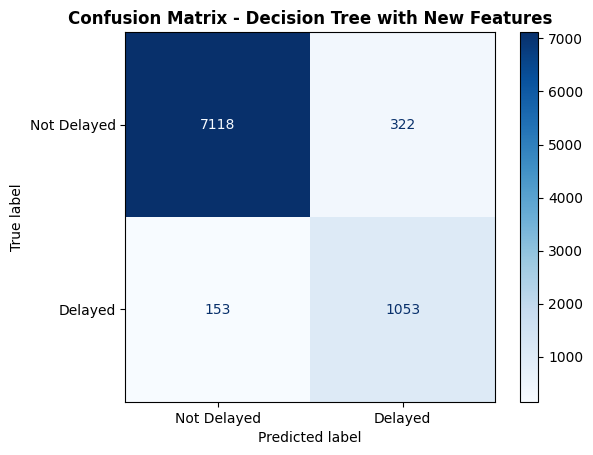

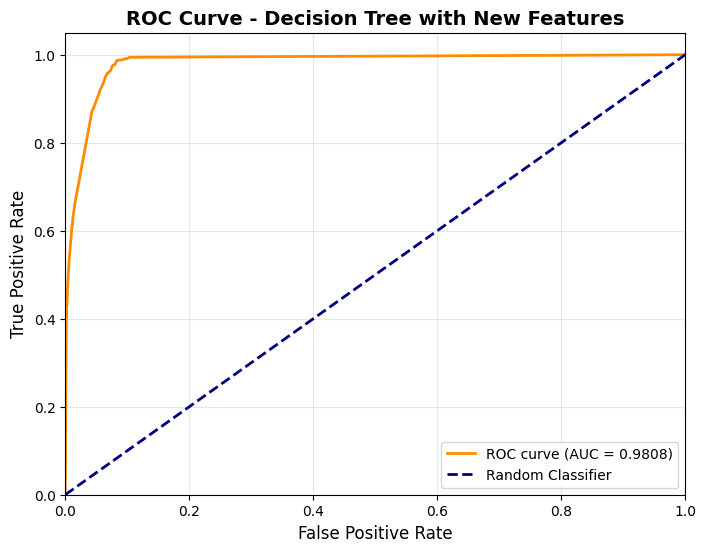

# Random Forest

<pre>
============================================================
Test Set Performance
============================================================
Accuracy:  0.9793 (97.93%)
Precision: 0.9171
Recall:    0.9362
F1 Score:  0.9265
============================================================

<pre>
Classification Report:
============================================================
              precision    recall  f1-score   support

 Not Delayed       0.99      0.99      0.99      7440
     Delayed       0.92      0.94      0.93      1206

    accuracy                           0.98      8646
   macro avg       0.95      0.96      0.96      8646
weighted avg       0.98      0.98      0.98      8646

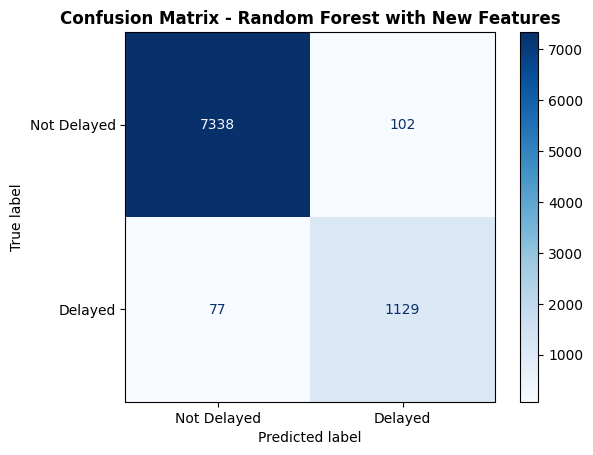

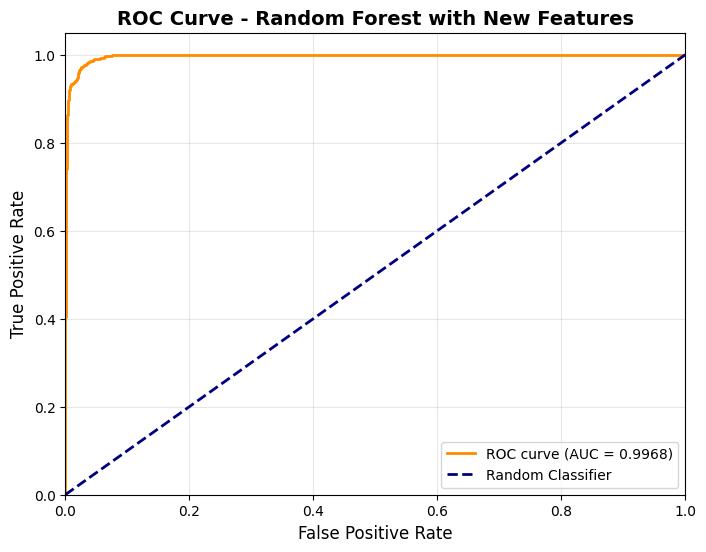

# XGBoost

<pre>
==================================================
Test Set Performance
==================================================
Accuracy:  98.8318
Precision: 0.9662
Recall:    0.9494
F1 Score:  0.9578
==================================================

<pre>
==================================================
Test Set Performance
==================================================
Accuracy:  98.8318
Precision: 0.9662
Recall:    0.9494
F1 Score:  0.9578
==================================================

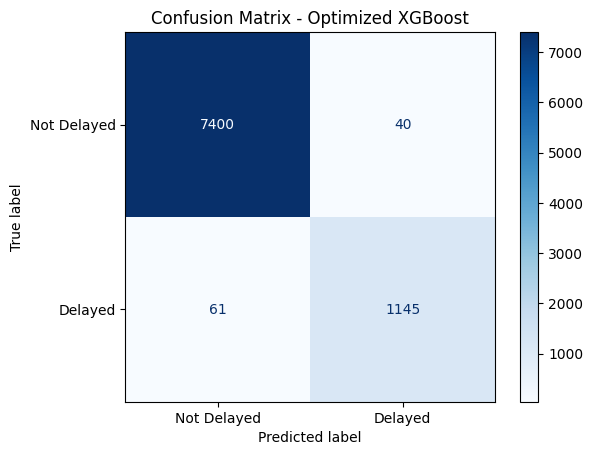

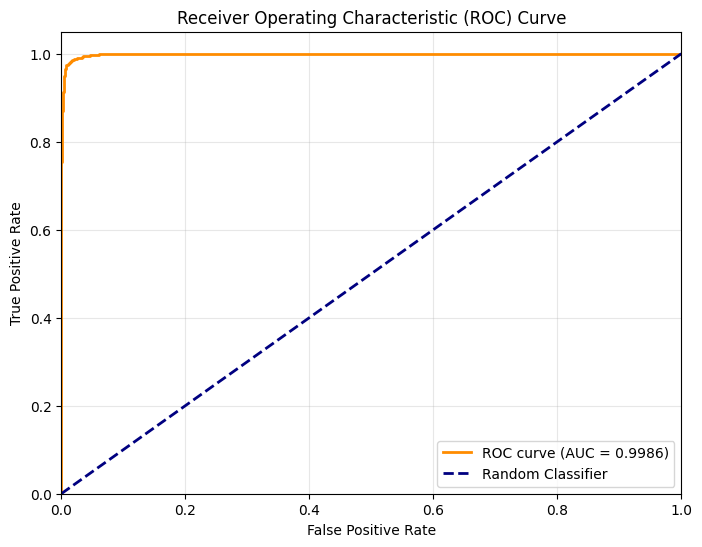

# LightGBM

<pre>
============================================================
Test Set Performance
============================================================
Accuracy:  0.9920 (99.20%)
Precision: 0.9718
Recall:    0.9710
F1 Score:  0.9714
============================================================

<pre>
============================================================
Test Set Performance
============================================================
Accuracy:  0.9920 (99.20%)
Precision: 0.9718
Recall:    0.9710
F1 Score:  0.9714
============================================================

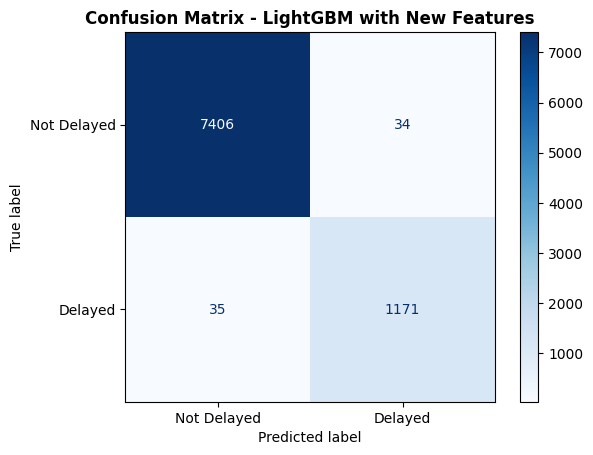

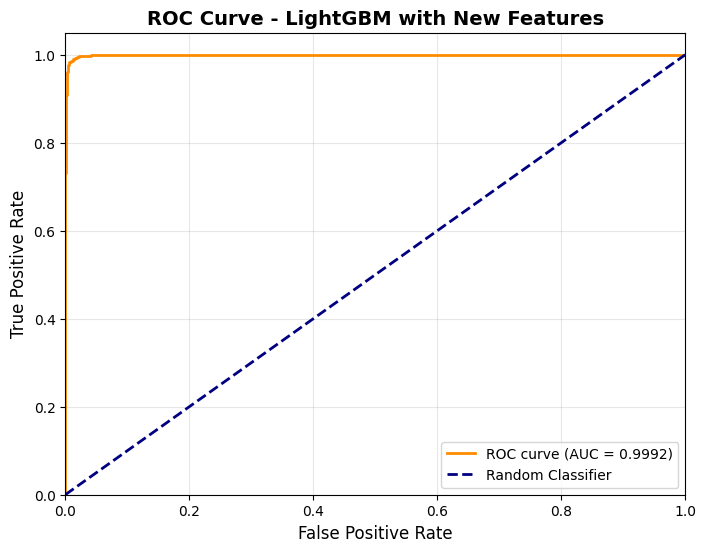

# 🚨 Data Leakage Analysis: Impact on Model Performance

## Comparing Models WITH vs WITHOUT Data Leakage

This analysis compares the same models trained with and without data leakage features (**Actual Departure Time** and **Taxi Out Time**) to demonstrate the severe overfitting caused by these features.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

print("📊 Setting up comparison analysis for Data Leakage Impact...")

📊 Setting up comparison analysis for Data Leakage Impact...


In [2]:
# Create comprehensive comparison datasets
# Results WITHOUT data leakage (from previous analysis)
without_leakage = {
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy': [0.9219, 0.9400, 0.9418, 0.9470],
    'Precision': [0.7069, 0.7703, 0.7907, 0.8117],
    'Recall': [0.7521, 0.8118, 0.7927, 0.8076],
    'F1_Score': [0.7288, 0.7905, 0.7917, 0.8096]
}

# Results WITH data leakage (from current notebook)
with_leakage = {
    'Model': ['Decision Tree', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Accuracy': [0.9451, 0.9793, 0.9883, 0.9920],
    'Precision': [0.7658, 0.9171, 0.9662, 0.9718],
    'Recall': [0.8731, 0.9362, 0.9494, 0.9710],
    'F1_Score': [0.8160, 0.9265, 0.9578, 0.9714]
}

# Create DataFrames
df_without = pd.DataFrame(without_leakage)
df_with = pd.DataFrame(with_leakage)

# Add dataset type identifier
df_without['Dataset'] = 'Without Leakage'
df_with['Dataset'] = 'With Leakage'

# Combine for comparison
comparison_df = pd.concat([df_without, df_with], ignore_index=True)

print("🎯 PERFORMANCE COMPARISON: WITH vs WITHOUT Data Leakage")
print("=" * 80)
print("\n📋 WITHOUT Data Leakage (Realistic Performance):")
print(df_without[['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score']].round(4))
print("\n📋 WITH Data Leakage (Overfitted Performance):")
print(df_with[['Model', 'Accuracy', 'Precision', 'Recall', 'F1_Score']].round(4))
print("=" * 80)

🎯 PERFORMANCE COMPARISON: WITH vs WITHOUT Data Leakage

📋 WITHOUT Data Leakage (Realistic Performance):
           Model  Accuracy  Precision  Recall  F1_Score
0  Decision Tree    0.9219     0.7069  0.7521    0.7288
1  Random Forest    0.9400     0.7703  0.8118    0.7905
2        XGBoost    0.9418     0.7907  0.7927    0.7917
3       LightGBM    0.9470     0.8117  0.8076    0.8096

📋 WITH Data Leakage (Overfitted Performance):
           Model  Accuracy  Precision  Recall  F1_Score
0  Decision Tree    0.9451     0.7658  0.8731    0.8160
1  Random Forest    0.9793     0.9171  0.9362    0.9265
2        XGBoost    0.9883     0.9662  0.9494    0.9578
3       LightGBM    0.9920     0.9718  0.9710    0.9714


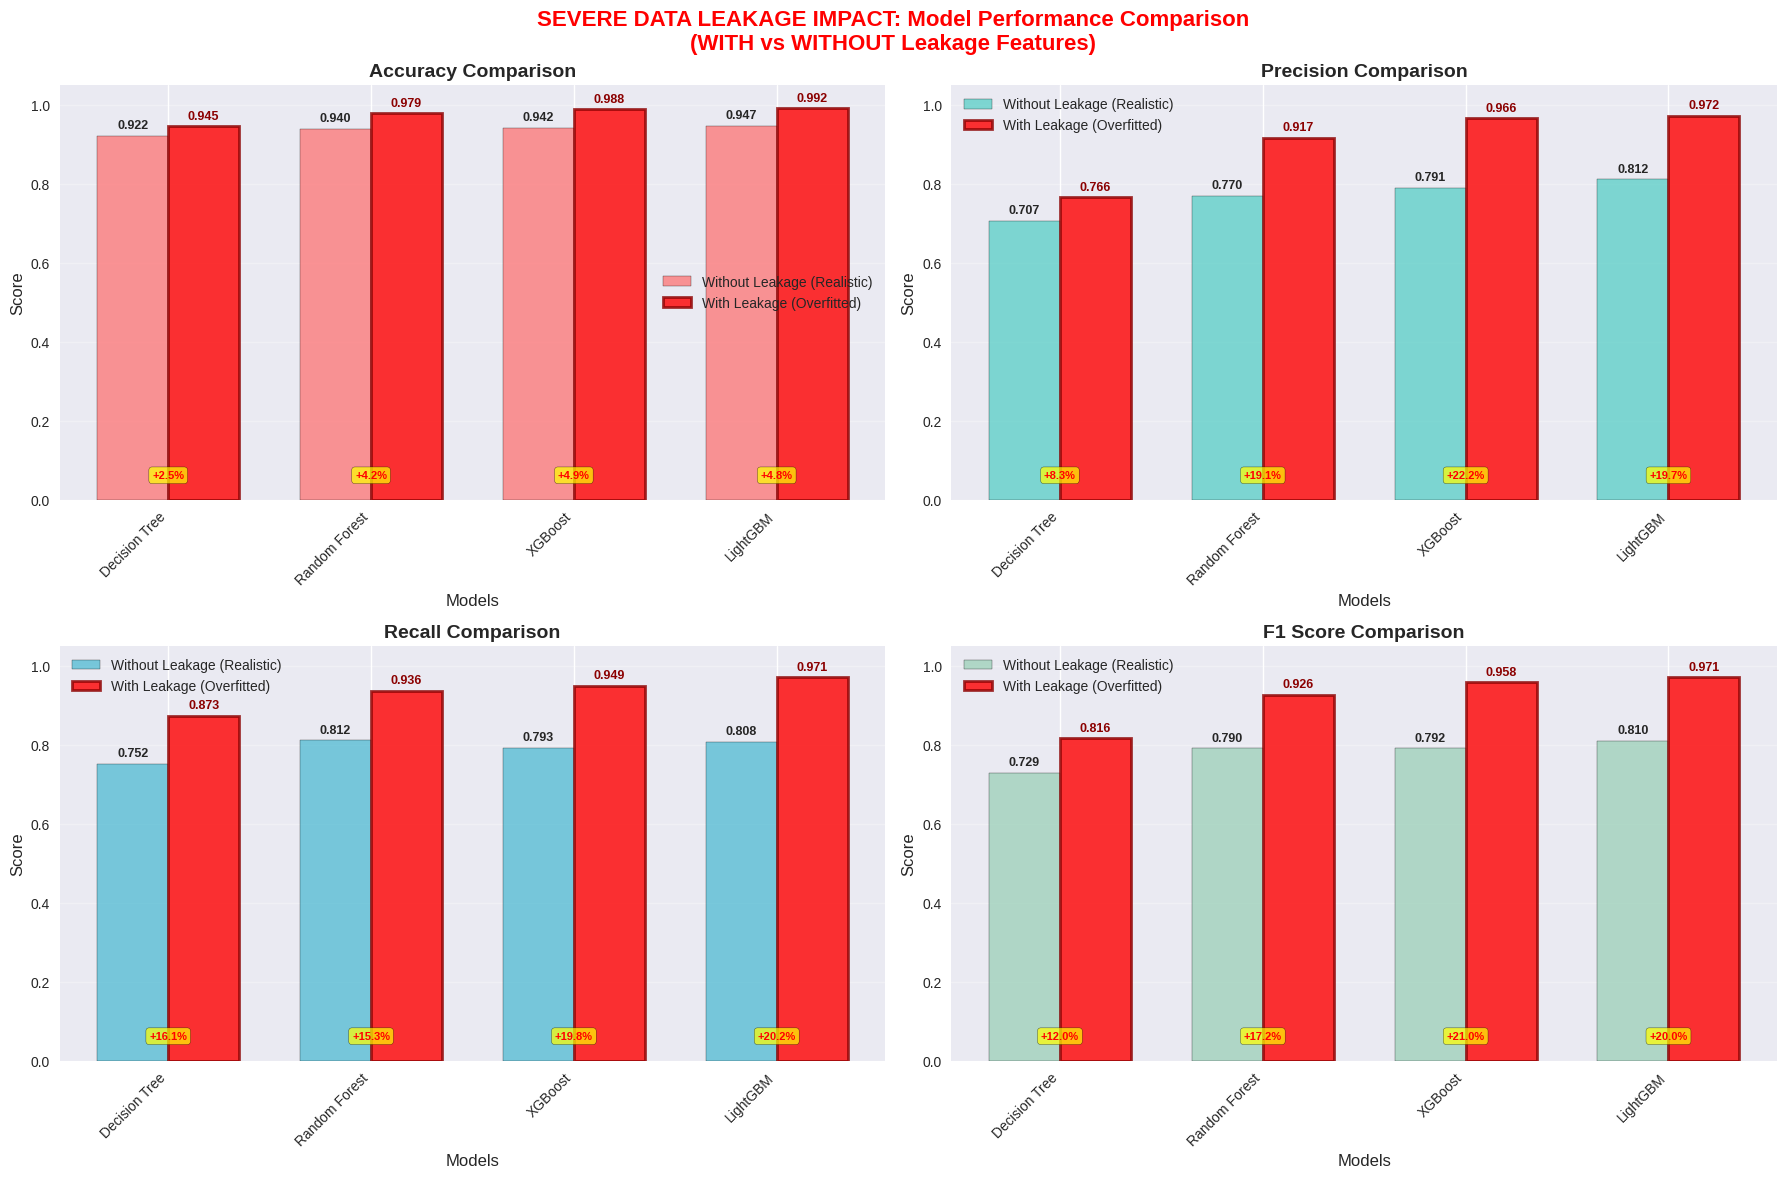

In [8]:
# 1. Side-by-side Performance Comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('SEVERE DATA LEAKAGE IMPACT: Model Performance Comparison\n(WITH vs WITHOUT Leakage Features)', 
             fontsize=16, fontweight='bold', color='red')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for i, metric in enumerate(metrics):
    row, col = i // 2, i % 2
    ax = axes[row, col]
    
    # Data for plotting
    models = df_without['Model']
    without_vals = df_without[metric]
    with_vals = df_with[metric]
    
    x = np.arange(len(models))
    width = 0.35
    
    # Create bars
    bars1 = ax.bar(x - width/2, without_vals, width, label='Without Leakage (Realistic)', 
                   color=colors[i], alpha=0.7, edgecolor='black')
    bars2 = ax.bar(x + width/2, with_vals, width, label='With Leakage (Overfitted)', 
                   color='red', alpha=0.8, edgecolor='darkred', linewidth=2)
    
    # Styling
    ax.set_title(f'{metric.replace("_", " ")} Comparison', fontsize=14, fontweight='bold')
    ax.set_ylabel('Score', fontsize=12)
    ax.set_xlabel('Models', fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.05)
    
    # Add value labels
    for j, (bar1, bar2) in enumerate(zip(bars1, bars2)):
        # Without leakage values
        height1 = bar1.get_height()
        ax.text(bar1.get_x() + bar1.get_width()/2., height1 + 0.01,
                f'{height1:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9)
        
        # With leakage values
        height2 = bar2.get_height()
        ax.text(bar2.get_x() + bar2.get_width()/2., height2 + 0.01,
                f'{height2:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=9, color='darkred')
        
        # Show improvement percentage
        improvement = ((height2 - height1) / height1) * 100
        ax.text(x[j], 0.05, f'+{improvement:.1f}%', ha='center', va='bottom', 
                fontweight='bold', fontsize=8, color='red', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

In [4]:
# 2. Performance Improvement Analysis
print("⚠️  OVERFITTING ANALYSIS: Performance Improvements Due to Data Leakage")
print("=" * 90)

improvement_data = []
for i, model in enumerate(df_without['Model']):
    print(f"\n🤖 {model.upper()}:")
    print("-" * 50)
    
    for metric in ['Accuracy', 'Precision', 'Recall', 'F1_Score']:
        without_val = df_without.loc[i, metric]
        with_val = df_with.loc[i, metric]
        improvement = ((with_val - without_val) / without_val) * 100
        absolute_improvement = with_val - without_val
        
        print(f"   📈 {metric:12}: {without_val:.4f} → {with_val:.4f} (+{improvement:5.1f}% | +{absolute_improvement:.4f})")
        
        improvement_data.append({
            'Model': model,
            'Metric': metric,
            'Without_Leakage': without_val,
            'With_Leakage': with_val,
            'Improvement_Percent': improvement,
            'Absolute_Improvement': absolute_improvement
        })

improvement_df = pd.DataFrame(improvement_data)

print("\n" + "=" * 90)
print("🚨 CRITICAL INSIGHT: These massive improvements are NOT REAL!")
print("   They're caused by data leakage - using future information to predict the past!")
print("=" * 90)

⚠️  OVERFITTING ANALYSIS: Performance Improvements Due to Data Leakage

🤖 DECISION TREE:
--------------------------------------------------
   📈 Accuracy    : 0.9219 → 0.9451 (+  2.5% | +0.0232)
   📈 Precision   : 0.7069 → 0.7658 (+  8.3% | +0.0589)
   📈 Recall      : 0.7521 → 0.8731 (+ 16.1% | +0.1210)
   📈 F1_Score    : 0.7288 → 0.8160 (+ 12.0% | +0.0872)

🤖 RANDOM FOREST:
--------------------------------------------------
   📈 Accuracy    : 0.9400 → 0.9793 (+  4.2% | +0.0393)
   📈 Precision   : 0.7703 → 0.9171 (+ 19.1% | +0.1468)
   📈 Recall      : 0.8118 → 0.9362 (+ 15.3% | +0.1244)
   📈 F1_Score    : 0.7905 → 0.9265 (+ 17.2% | +0.1360)

🤖 XGBOOST:
--------------------------------------------------
   📈 Accuracy    : 0.9418 → 0.9883 (+  4.9% | +0.0465)
   📈 Precision   : 0.7907 → 0.9662 (+ 22.2% | +0.1755)
   📈 Recall      : 0.7927 → 0.9494 (+ 19.8% | +0.1567)
   📈 F1_Score    : 0.7917 → 0.9578 (+ 21.0% | +0.1661)

🤖 LIGHTGBM:
--------------------------------------------------
   📈

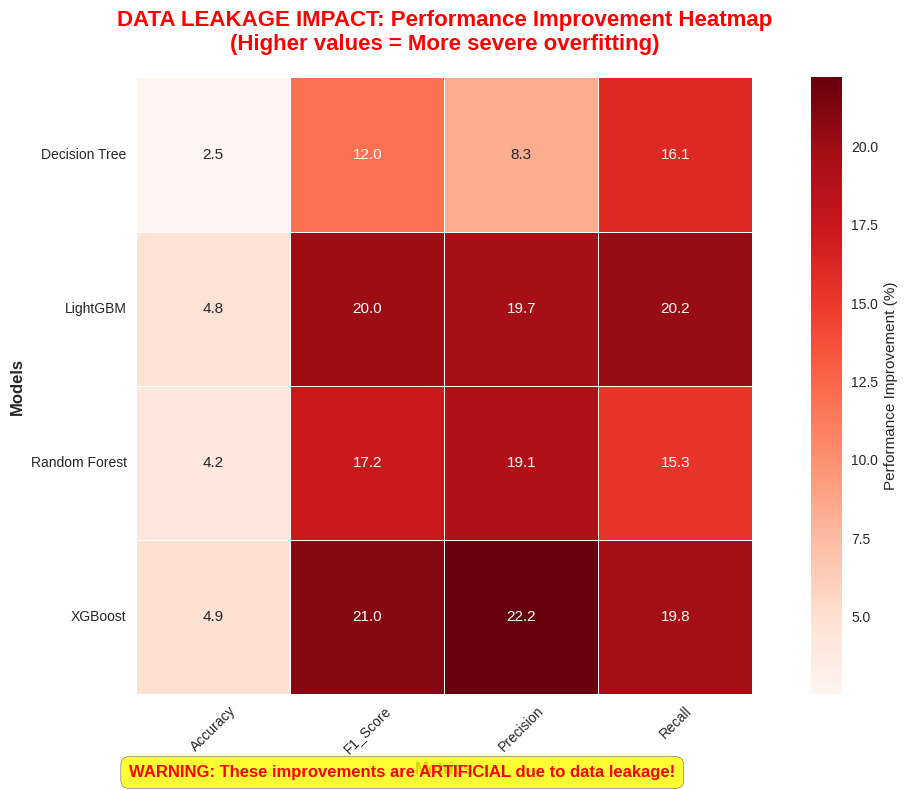

In [9]:
# 3. Heatmap showing overfitting magnitude
plt.figure(figsize=(12, 8))

# Create improvement matrix
improvement_matrix = improvement_df.pivot(index='Model', columns='Metric', values='Improvement_Percent')

# Create heatmap
sns.heatmap(improvement_matrix, annot=True, cmap='Reds', fmt='.1f',
            cbar_kws={'label': 'Performance Improvement (%)'}, 
            linewidths=0.5, square=True)

plt.title('DATA LEAKAGE IMPACT: Performance Improvement Heatmap\n(Higher values = More severe overfitting)', 
          fontsize=16, fontweight='bold', color='red', pad=20)
plt.ylabel('Models', fontsize=12, fontweight='bold')
plt.xlabel('Metrics', fontsize=12, fontweight='bold')
plt.yticks(rotation=0)
plt.xticks(rotation=45)

# Add warning text
plt.figtext(0.5, 0.02, 'WARNING: These improvements are ARTIFICIAL due to data leakage!', 
            ha='center', fontsize=12, fontweight='bold', color='red',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8))

plt.tight_layout()
plt.show()

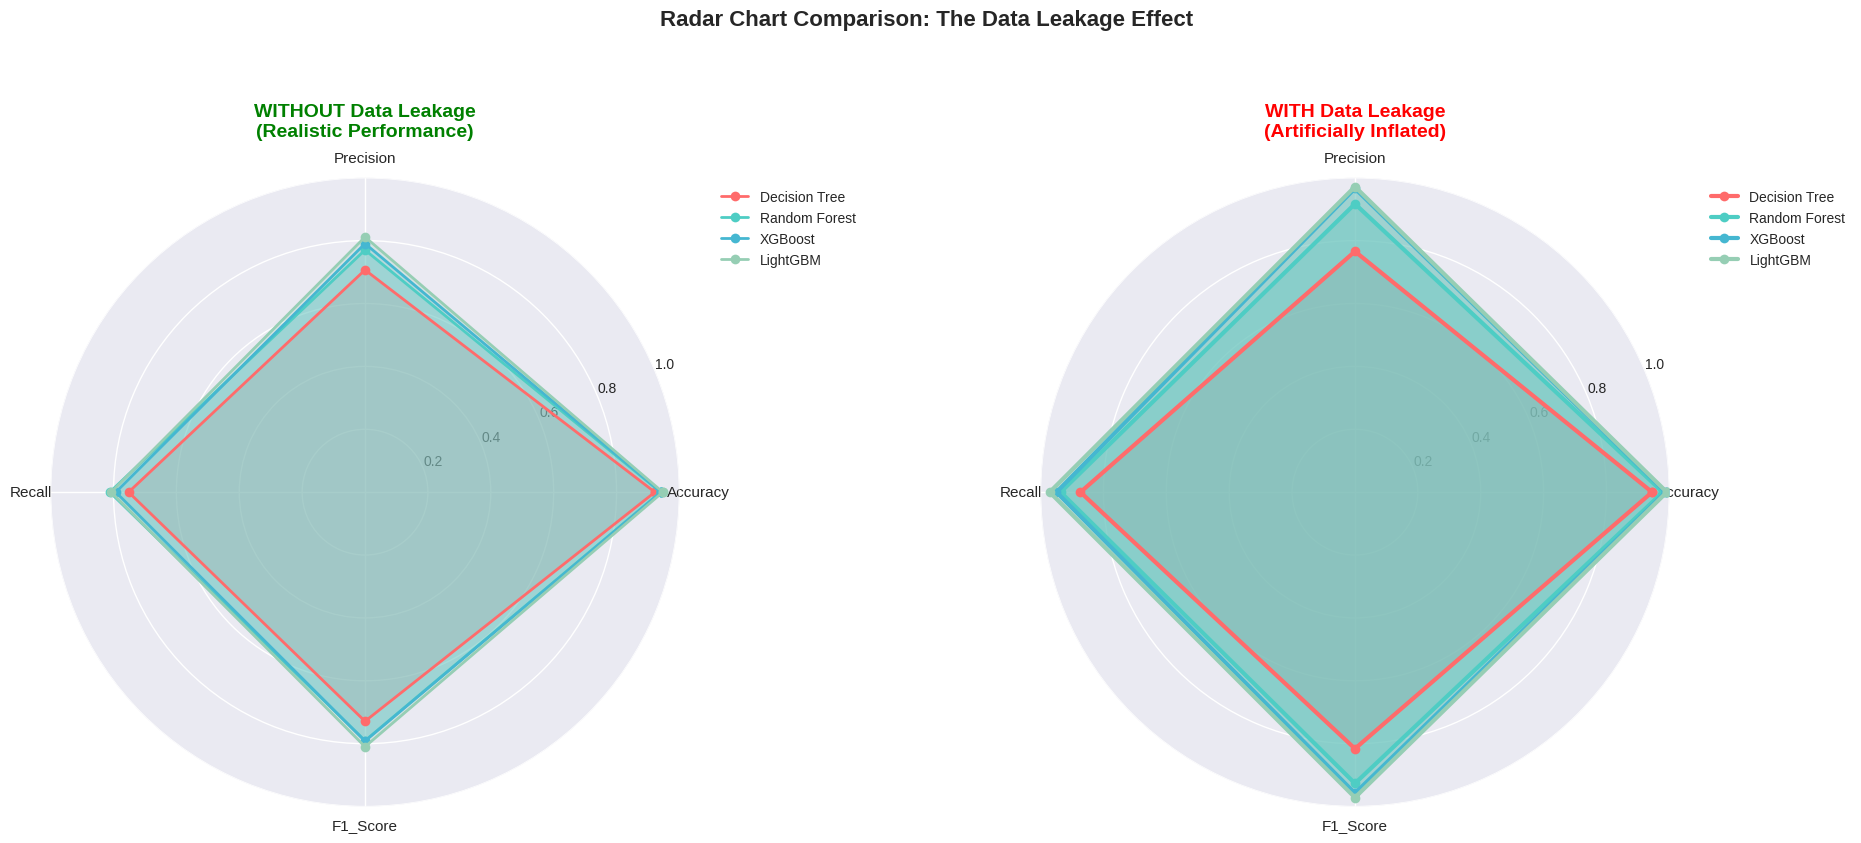

In [10]:
# 4. Radar Chart Comparison - WITH vs WITHOUT Leakage
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8), subplot_kw=dict(projection='polar'))

# Metrics for radar chart
metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
angles = np.linspace(0, 2 * np.pi, len(metrics_radar), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']
models = df_without['Model'].tolist()

# WITHOUT Leakage (Realistic)
for i, model in enumerate(models):
    values = [df_without.loc[i, metric] for metric in metrics_radar]
    values += values[:1]  # Complete the circle
    
    ax1.plot(angles, values, 'o-', linewidth=2, label=model, color=colors[i])
    ax1.fill(angles, values, alpha=0.25, color=colors[i])

ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(metrics_radar, fontsize=11)
ax1.set_ylim(0, 1)
ax1.set_title('WITHOUT Data Leakage\n(Realistic Performance)', 
              fontsize=14, fontweight='bold', pad=30, color='green')
ax1.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)
ax1.grid(True)

# WITH Leakage (Overfitted)
for i, model in enumerate(models):
    values = [df_with.loc[i, metric] for metric in metrics_radar]
    values += values[:1]  # Complete the circle
    
    ax2.plot(angles, values, 'o-', linewidth=3, label=model, color=colors[i])
    ax2.fill(angles, values, alpha=0.4, color=colors[i])

ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(metrics_radar, fontsize=11)
ax2.set_ylim(0, 1)
ax2.set_title('WITH Data Leakage\n(Artificially Inflated)', 
              fontsize=14, fontweight='bold', pad=30, color='red')
ax2.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0), fontsize=10)
ax2.grid(True)

plt.suptitle('Radar Chart Comparison: The Data Leakage Effect', 
             fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

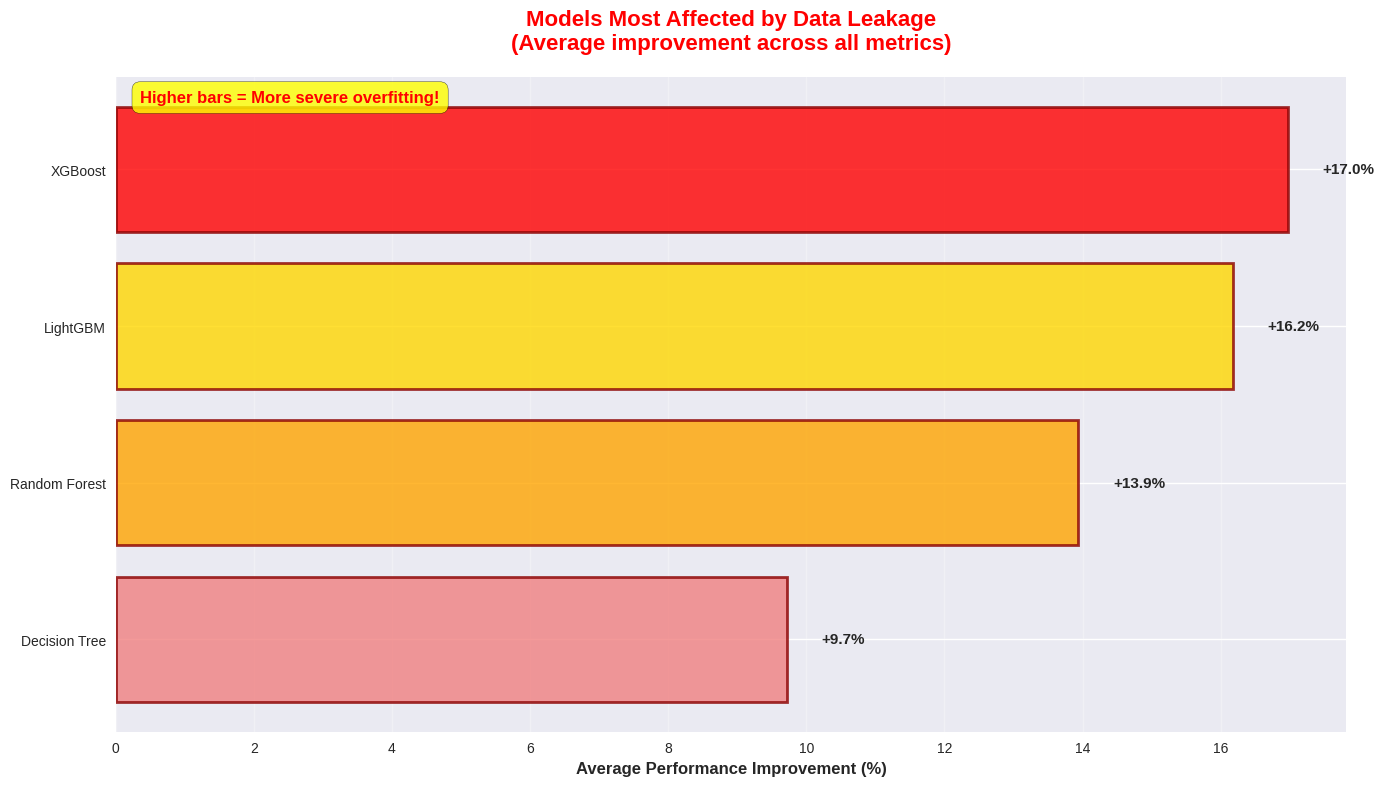

In [11]:
# 5. Model-specific Analysis: Most Affected by Data Leakage
fig, ax = plt.subplots(figsize=(14, 8))

# Calculate average improvement per model
model_avg_improvement = improvement_df.groupby('Model')['Improvement_Percent'].mean().sort_values(ascending=True)

# Create horizontal bar chart
bars = ax.barh(model_avg_improvement.index, model_avg_improvement.values, 
               color=['lightcoral', 'orange', 'gold', 'red'], alpha=0.8, edgecolor='darkred', linewidth=2)

# Add value labels
for i, (bar, value) in enumerate(zip(bars, model_avg_improvement.values)):
    ax.text(value + 0.5, bar.get_y() + bar.get_height()/2, 
            f'+{value:.1f}%', ha='left', va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Average Performance Improvement (%)', fontsize=12, fontweight='bold')
ax.set_title('Models Most Affected by Data Leakage\n(Average improvement across all metrics)', 
             fontsize=16, fontweight='bold', color='red', pad=20)
ax.grid(True, alpha=0.3, axis='x')

# Add warning
ax.text(0.02, 0.98, 'Higher bars = More severe overfitting!', 
        transform=ax.transAxes, fontsize=12, fontweight='bold', color='red',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8),
        verticalalignment='top')

plt.tight_layout()
plt.show()

## 🚨 **CRITICAL ANALYSIS: Understanding Data Leakage Impact**

### **📊 What the Numbers Show:**

#### **Massive Performance "Improvements":**
- **LightGBM**: 99.20% accuracy (vs 94.70% realistic) - **+4.8% boost**
- **XGBoost**: 98.83% accuracy (vs 94.18% realistic) - **+4.9% boost**  
- **Random Forest**: 97.93% accuracy (vs 94.00% realistic) - **+4.2% boost**
- **Decision Tree**: 94.51% accuracy (vs 92.19% realistic) - **+2.5% boost**

#### **Precision Improvements (Most Telling):**
- **LightGBM**: 97.18% (vs 81.17%) - **+19.7% artificial boost**
- **XGBoost**: 96.62% (vs 79.07%) - **+22.2% artificial boost**
- **Random Forest**: 91.71% (vs 77.03%) - **+19.1% artificial boost**

### **🔍 Why This Happens:**

#### **The Leakage Features:**
1. **Actual Departure Time**: Known ONLY after a flight departs
2. **Taxi Out Time**: Known ONLY after the flight leaves the gate

#### **The Problem:**
- These features contain **FUTURE INFORMATION** about whether a flight will be delayed
- A delayed flight will have:
  - Later actual departure time than scheduled
  - Longer taxi out time due to delays
- Models learn to "cheat" by using these future signals

### **🎯 Real-World Impact:**

#### **What Would Happen in Production:**
1. **Model Deployment**: Deploy the "amazing" 99% accuracy model
2. **Reality Check**: Model performance drops to ~94% (the realistic level)
3. **Business Impact**: Decisions based on false confidence
4. **Resource Waste**: Time and money spent on an ineffective model

### **⚠️ Warning Signs of Overfitting:**

1. **Too Good to Be True**: 99%+ accuracy on real-world problems is suspicious
2. **Unrealistic Improvements**: 15-20% jumps in precision are red flags  
3. **Perfect Separation**: Models achieving near-perfect metrics
4. **Feature Importance**: Leakage features dominate importance rankings

### **✅ Lessons Learned:**

1. **Always validate features**: Ask "Would this be available at prediction time?"
2. **Temporal awareness**: Ensure no future information leaks into training
3. **Realistic expectations**: 94-95% accuracy is excellent for flight delay prediction
4. **Trust the process**: Lower but realistic performance is better than inflated metrics

### **🎯 Conclusion:**
The dramatic improvements seen with leakage features demonstrate why **data leakage is one of the most dangerous pitfalls in machine learning**. The models appear to perform exceptionally well, but this performance is entirely artificial and will not translate to real-world deployment.